# [5.2] Gemma Scope and Feature Steering - Solutions

## Core Question

Can a sparse feature chosen on discovery examples predict a held-out concept and causally move a target score, while random-feature and norm-matched random-direction controls fail?

You will answer this twice. First, an exact sparse-feature organism gives ground truth. Then the same JumpReLU equations and intervention hooks are used with the pinned released Gemma Scope SAE and its matching Gemma 3 1B model on CPU.

The exact organism supports a causal claim because its sparse code and readout are known. The real-model probe supplies real activations and real downstream logits, but its small hand-built prompt split supports only a narrow feature hypothesis.

<img src="../../instructions/assets/gemma_scope_exact_organism_signature.png" width="980">

## Section Metadata

| Release field | Value |
| --- | --- |
| Exercise | `EXERCISE_ID = "5_2_gemma_scope_and_feature_steering"` |
| Ground-truth tier | `GT_TIER = "GT-3"` |
| Difficulty | `DIFFICULTY = 3` |
| Importance | `IMPORTANCE = 4` |
| Expected runtime | `EXPECTED_RUNTIME = "seconds on toy contract; minutes on local real-model path"` |
| GPU Contract | `REQUIRES_GPU = True` for the optional release verification; the exact organism and released-SAE tensor checks run on CPU. |

## Learning Objectives

By the end of this notebook, you should be able to:

- implement JumpReLU encoding and SAE decoding;
- select a feature on discovery data and evaluate it on at least 20 held-out examples;
- inspect real text examples rather than a scalar report;
- implement decoder-vector steering and progressive feature ablation;
- compare against random features, shuffled labels, and a norm-matched random direction;
- load the pinned Gemma Scope tensors and intervene at `model.layers.13.output`.

The visible results are generated in this notebook. `verification_report.json` is separate release evidence and is not used below.


In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import matplotlib.pyplot as plt
import numpy as np
import torch as t
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

chapter = "chapter5_modern_architectures"
section = "part2_gemma_scope_feature_steering"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"
for path in (root_dir, exercises_dir):
    if str(path) not in sys.path:
        sys.path.append(str(path))

import part2_gemma_scope_feature_steering.tests as tests

t.set_grad_enabled(False)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 10,
})

TARGET = "#B43A32"
FEATURE_CONTROL = "#167D8D"
DIRECTION_CONTROL = "#5F6875"
SHUFFLE_CONTROL = "#D39A2C"


## Cold open: the evidence ladder

A dashboard shows that one latent fires on prompts about tensors, Python, and APIs. Three different claims are easy to blur together:

1. **Representation:** the latent separates technical prompts from matched narrative prompts.
2. **Function:** adding or removing its decoder direction changes a downstream score.
3. **Interpretation:** "technical text" is a useful description that survives new data and controls.

This notebook keeps those claims separate. The exact organism makes the first two mathematically checkable. The real Gemma probe asks whether a released latent passes the same ladder on a small sample.

<details><summary>Interpretation - what would falsify the claim?</summary>

A target feature that performs like shuffled labels on held-out examples fails the representation claim. A steering curve that is no stronger than a norm-matched random direction, or an ablation curve that matches random-feature ablation, fails the function claim.

</details>


## 1. Exact sparse-feature organism

The organism has eight declared sparse features mixed into a 12-dimensional residual stream. Its decoder rows are orthonormal, its encoder is the transpose, and every active feature lies above a fixed JumpReLU threshold. Consequently, the sparse code and reconstruction are exact up to floating-point error.

The text is only an index into designed ground-truth factors. This is an exact causal model of an SAE intervention, not evidence that language models encode these factors this cleanly.


In [2]:
FEATURE_NAMES = [
    "technical", "narrative", "positive", "question",
    "number", "first_person", "past_tense", "instruction",
]

TECHNICAL_BASES = [
    "A parser validates a JSON object", "A tensor stores a matrix product",
    "A compiler lowers a function", "An API returns a typed response",
    "A unit test checks a decoder", "A kernel multiplies two arrays",
    "A tokenizer masks padding", "A gradient updates the weights",
    "A cache stores attention keys", "A schema constrains tool arguments",
    "A sparse code reconstructs a residual", "A hook captures layer output",
    "A benchmark measures latency", "A debugger traces the call stack",
    "A batch contains token sequences", "A loss compares model logits",
    "A vector index retrieves documents", "A dtype controls precision",
    "A checkpoint stores parameters", "A test isolates a regression",
]
NARRATIVE_BASES = [
    "A lantern glows beside the river", "A child watches clouds cross the hill",
    "The garden smells of rain", "A boat drifts across the lake",
    "Fresh bread cools by the window", "Friends listen to music in the park",
    "Snow settles on the empty road", "Waves reach the beach at dusk",
    "A traveler rests beneath an oak", "Moonlight falls across the porch",
    "A painter opens a blue umbrella", "The village wakes before sunrise",
    "A kettle whistles in the kitchen", "Leaves turn slowly in the wind",
    "A violin echoes through the hall", "Candles flicker near the doorway",
    "A dog sleeps beside the fire", "Footsteps fade along the path",
    "A letter waits on the table", "Lanterns shine during the festival",
]

def build_exact_organism() -> dict[str, object]:
    rows = []
    sparse_rows = []
    for label, bases in ((1, TECHNICAL_BASES), (0, NARRATIVE_BASES)):
        for index, base in enumerate(bases):
            text = base
            if index % 4 >= 2:
                text = "I remember that " + text[0].lower() + text[1:]
            if index % 4 < 2:
                text += "?"
            else:
                text += "."
            if index % 3 == 0:
                text += f" It mentions {index + 1} details."
            if index % 5 < 2:
                text += " It worked well."
            if index % 5 in (2, 3):
                text += " Please explain."

            features = t.zeros(len(FEATURE_NAMES))
            features[0] = (1.0 + 0.1 * (index % 4)) * label
            features[1] = (1.0 + 0.1 * (index % 4)) * (1 - label)
            nuisance_active = [
                index % 5 < 2,
                index % 4 < 2,
                index % 3 == 0,
                index % 4 >= 2,
                index % 5 < 2,
                index % 5 in (2, 3),
            ]
            for feature_id, active in enumerate(nuisance_active, start=2):
                if active:
                    features[feature_id] = 0.65 + 0.05 * (index % 3)
            rows.append({
                "text": text,
                "label": label,
                "split": "discovery" if index < 8 else "heldout",
            })
            sparse_rows.append(features)

    generator = t.Generator().manual_seed(5)
    basis, _ = t.linalg.qr(t.randn(12, len(FEATURE_NAMES), generator=generator))
    w_dec = basis.T.contiguous()
    w_enc = w_dec.T.contiguous()
    b_dec = t.linspace(-0.15, 0.15, 12)
    b_enc = t.zeros(len(FEATURE_NAMES))
    threshold = t.full((len(FEATURE_NAMES),), 0.25)
    ground_truth = t.stack(sparse_rows)
    residuals = ground_truth @ w_dec + b_dec
    return {
        "rows": rows,
        "ground_truth": ground_truth,
        "residuals": residuals,
        "w_enc": w_enc,
        "w_dec": w_dec,
        "b_enc": b_enc,
        "b_dec": b_dec,
        "threshold": threshold,
    }

organism = build_exact_organism()
print("Cold-open examples from the exact organism:")
for row in organism["rows"][:2] + organism["rows"][20:22]:
    print(f"  label={row['label']} split={row['split']:<9} | {row['text']}")
print("Ground-truth sparse-code shape:", tuple(organism["ground_truth"].shape))


Cold-open examples from the exact organism:
  label=1 split=discovery | A parser validates a JSON object? It mentions 1 details. It worked well.
  label=1 split=discovery | A tensor stores a matrix product? It worked well.
  label=0 split=discovery | A lantern glows beside the river? It mentions 1 details. It worked well.
  label=0 split=discovery | A child watches clouds cross the hill? It worked well.
Ground-truth sparse-code shape: (40, 8)


### Exercise - implement JumpReLU encode and decode

Implement the core SAE equations:

$$z_{pre} = (x-b_{dec})W_{enc}+b_{enc}$$
$$z = z_{pre} 1[z_{pre} > threshold]$$
$$\hat{x} = zW_{dec}+b_{dec}$$

The strict `>` matters at the threshold boundary.

<details><summary>Help - common bug: transposing the encoder or decoder</summary>

`x` ends in `d_model`, `W_enc` has shape `(d_model, n_features)`, and `W_dec` has shape `(n_features, d_model)`. PyTorch broadcasts both bias vectors over leading dimensions.

</details>

<details><summary>Solution</summary>

```python
def jumprelu_encode(x, *, w_enc, b_enc, b_dec, threshold):
    pre = (x.float() - b_dec.float()) @ w_enc.float() + b_enc.float()
    return pre * (pre > threshold.float())

def sae_decode(feature_acts, *, w_dec, b_dec):
    return feature_acts.float() @ w_dec.float() + b_dec.float()
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_jumprelu_encode_decode` passed!
Maximum code error: < 1e-5
Maximum reconstruction error: < 1e-5
```

</details>


In [3]:
def jumprelu_encode(
    x: t.Tensor,
    *,
    w_enc: t.Tensor,
    b_enc: t.Tensor,
    b_dec: t.Tensor,
    threshold: t.Tensor,
) -> t.Tensor:
    """Encode residual vectors with the JumpReLU SAE equations."""
    pre = (x.float() - b_dec.float()) @ w_enc.float() + b_enc.float()
    return pre * (pre > threshold.float())


def sae_decode(
    feature_acts: t.Tensor,
    *,
    w_dec: t.Tensor,
    b_dec: t.Tensor,
) -> t.Tensor:
    """Decode sparse feature activations into the residual stream."""
    return feature_acts.float() @ w_dec.float() + b_dec.float()
tests.test_jumprelu_encode_decode(jumprelu_encode, sae_decode)

exact_feature_acts = jumprelu_encode(
    organism["residuals"],
    w_enc=organism["w_enc"],
    b_enc=organism["b_enc"],
    b_dec=organism["b_dec"],
    threshold=organism["threshold"],
)
exact_reconstruction = sae_decode(
    exact_feature_acts,
    w_dec=organism["w_dec"],
    b_dec=organism["b_dec"],
)
code_error = (exact_feature_acts - organism["ground_truth"]).abs().max().item()
reconstruction_error = (exact_reconstruction - organism["residuals"]).abs().max().item()
print(f"Maximum code error: {code_error:.2e}")
print(f"Maximum reconstruction error: {reconstruction_error:.2e}")


All tests in `test_jumprelu_encode_decode` passed!
Maximum code error: 4.77e-07
Maximum reconstruction error: 3.58e-07


<details><summary>Interpretation - what did exact reconstruction establish?</summary>

It established that the equations and intervention basis are correct for this organism. It did not establish that every SAE feature in a trained model is monosemantic, or that low reconstruction error implies an interpretable dictionary.

</details>


## 2. Discover a feature, then freeze the hypothesis

Feature selection uses only the 16 discovery examples. Evaluation uses 24 held-out examples. Implement a mean-difference selector, tie-aware ROC AUC, and top-example lookup. Looking at held-out labels while choosing the feature would leak the answer.

### Exercise - selection, AUC, and visible examples

<details><summary>Help - common bug: assigning distinct ranks to tied scores</summary>

Sort scores in ascending order, assign average 1-indexed ranks to tied groups, and use the Mann-Whitney rank formula. A constant nuisance feature should have AUC `0.5`.

</details>

<details><summary>Solution</summary>

```python
def select_feature_by_mean_difference(scores, labels, discovery_mask):
    discovery_scores = scores[discovery_mask]
    discovery_labels = labels[discovery_mask]
    margin = discovery_scores[discovery_labels].mean(0) - discovery_scores[~discovery_labels].mean(0)
    return int(margin.argmax().item())

def binary_roc_auc(scores, labels):
    scores, labels = scores.flatten().float(), labels.flatten().bool()
    order = scores.argsort()
    sorted_scores = scores[order]
    ranks_sorted = t.empty_like(sorted_scores)
    start = 0
    for count in t.unique_consecutive(sorted_scores, return_counts=True)[1].tolist():
        end = start + count
        ranks_sorted[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = ranks_sorted
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    return float(((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)).item())

def topk_example_indices(scores, k=5):
    return scores.flatten().topk(min(k, scores.numel())).indices
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_feature_discovery_and_heldout_scoring` passed!
Selected feature: 0 (technical)
Held-out AUC: 1.000 across 24 examples
Random-feature AUCs: all 0.500
```

</details>


In [4]:
def select_feature_by_mean_difference(
    feature_scores: t.Tensor,
    labels: t.Tensor,
    discovery_mask: t.Tensor,
) -> int:
    """Choose a feature using discovery rows only."""
    feature_scores = feature_scores.float()
    labels = labels.bool()
    discovery_mask = discovery_mask.bool()
    discovery_scores = feature_scores[discovery_mask]
    discovery_labels = labels[discovery_mask]
    if not bool(discovery_labels.any()) or not bool((~discovery_labels).any()):
        raise ValueError("Discovery data needs positive and negative examples.")
    margin = (
        discovery_scores[discovery_labels].mean(dim=0)
        - discovery_scores[~discovery_labels].mean(dim=0)
    )
    return int(margin.argmax().item())


def binary_roc_auc(scores: t.Tensor, labels: t.Tensor) -> float:
    """Return binary ROC AUC with average ranks for ties."""
    scores = scores.detach().flatten().float()
    labels = labels.detach().flatten().bool()
    if scores.numel() != labels.numel():
        raise ValueError("scores and labels must have equal length.")
    n_pos = int(labels.sum().item())
    n_neg = int((~labels).sum().item())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUC needs both classes.")
    order = scores.argsort()
    sorted_scores = scores[order]
    ranks_sorted = t.empty_like(sorted_scores)
    _, counts = t.unique_consecutive(sorted_scores, return_counts=True)
    start = 0
    for count in counts.tolist():
        end = start + count
        ranks_sorted[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = ranks_sorted
    numerator = ranks[labels].sum() - n_pos * (n_pos + 1) / 2
    return float((numerator / (n_pos * n_neg)).item())


def topk_example_indices(scores: t.Tensor, k: int = 5) -> t.Tensor:
    """Return indices of the k highest-scoring examples."""
    flat_scores = scores.detach().flatten()
    return flat_scores.topk(min(k, flat_scores.numel())).indices
tests.test_feature_discovery_and_heldout_scoring(
    select_feature_by_mean_difference,
    binary_roc_auc,
    topk_example_indices,
)


All tests in `test_feature_discovery_and_heldout_scoring` passed!


In [5]:
exact_labels = t.tensor([row["label"] for row in organism["rows"]], dtype=t.bool)
exact_discovery = t.tensor(
    [row["split"] == "discovery" for row in organism["rows"]], dtype=t.bool
)
# Preserve the organism's declared ties after float32 encode/decode noise.
exact_scoring_acts = exact_feature_acts.round(decimals=5)
selected_feature_id = select_feature_by_mean_difference(
    exact_scoring_acts, exact_labels, exact_discovery
)
exact_heldout = ~exact_discovery
heldout_scores = exact_scoring_acts[exact_heldout, selected_feature_id]
heldout_labels = exact_labels[exact_heldout]
heldout_rows = [row for row in organism["rows"] if row["split"] == "heldout"]
heldout_auc = binary_roc_auc(heldout_scores, heldout_labels)
random_feature_ids = list(range(2, len(FEATURE_NAMES)))
random_feature_aucs = [
    binary_roc_auc(exact_scoring_acts[exact_heldout, feature_id], heldout_labels)
    for feature_id in random_feature_ids
]

print(f"Selected feature: {selected_feature_id} ({FEATURE_NAMES[selected_feature_id]})")
print(f"Held-out AUC: {heldout_auc:.3f} across {int(exact_heldout.sum())} examples")
print("Random-feature AUCs:", [round(value, 3) for value in random_feature_aucs])
print("\nTop held-out examples:")
for index in topk_example_indices(heldout_scores, k=5).tolist():
    row = heldout_rows[index]
    print(f"  score={heldout_scores[index]:.2f} label={row['label']} | {row['text']}")
print("\nLowest held-out examples:")
for index in heldout_scores.argsort()[:3].tolist():
    row = heldout_rows[index]
    print(f"  score={heldout_scores[index]:.2f} label={row['label']} | {row['text']}")


Selected feature: 0 (technical)
Held-out AUC: 1.000 across 24 examples
Random-feature AUCs: [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

Top held-out examples:
  score=1.30 label=1 | I remember that a test isolates a regression.
  score=1.30 label=1 | I remember that a loss compares model logits. It mentions 16 details. It worked well.
  score=1.30 label=1 | I remember that a hook captures layer output. It worked well.
  score=1.20 label=1 | I remember that a sparse code reconstructs a residual. It worked well.
  score=1.20 label=1 | I remember that a batch contains token sequences.

Lowest held-out examples:
  score=0.00 label=0 | A traveler rests beneath an oak? Please explain.
  score=0.00 label=0 | I remember that lanterns shine during the festival.
  score=0.00 label=0 | I remember that a letter waits on the table. It mentions 19 details. Please explain.


<details><summary>Interpretation - why the top examples are not the result</summary>

The examples make the proposed meaning legible, but the held-out AUC is the test. Here the result is exact because the target latent is part of the organism's declared ground truth. In a real model, equally clean examples can still arise from correlated tokens or prompt format.

</details>


## 3. Cause and remove the target contribution

Steering adds `coefficient * decoder_direction` to the residual stream. Progressive ablation subtracts a fraction of the feature's own decoded contribution. Implement both operations and a direction score.

### Exercise - steering and progressive ablation

<details><summary>Help - common bug: subtracting a unit decoder direction</summary>

The decoded contribution of feature `i` is `feature_acts[..., i, None] * W_dec[i]`. Multiplying this by an ablation fraction from 0 to 1 gives a curve rather than a single before/after point.

</details>

<details><summary>Solution</summary>

```python
def steer_residual(residual, direction, coefficient):
    return residual + float(coefficient) * direction

def ablate_feature(residual, feature_acts, decoder_vectors, feature_id, fraction=1.0):
    contribution = feature_acts[..., feature_id, None] * decoder_vectors[feature_id]
    return residual - float(fraction) * contribution

def direction_score(residual, direction):
    return (residual.float() * direction.float()).sum(dim=-1)
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_feature_steering_and_ablation` passed!
Exact held-out AUC = 1.000; random features = 0.500; shuffled labels about 0.500
Steering slope: target > random direction and random feature
Full ablation: target score approaches 0; random-feature ablation stays at baseline
```

</details>


In [6]:
def steer_residual(
    residual: t.Tensor,
    direction: t.Tensor,
    coefficient: float,
) -> t.Tensor:
    """Add a decoder direction to every residual vector."""
    return residual + float(coefficient) * direction.to(residual)


def ablate_feature(
    residual: t.Tensor,
    feature_acts: t.Tensor,
    decoder_vectors: t.Tensor,
    feature_id: int,
    fraction: float = 1.0,
) -> t.Tensor:
    """Subtract a fraction of one feature's decoded contribution."""
    if not 0.0 <= float(fraction) <= 1.0:
        raise ValueError("fraction must lie in [0, 1].")
    contribution = (
        feature_acts[..., feature_id, None].to(residual)
        * decoder_vectors[feature_id].to(residual)
    )
    return residual - float(fraction) * contribution


def direction_score(residual: t.Tensor, direction: t.Tensor) -> t.Tensor:
    """Project residual vectors onto a direction."""
    return (residual.float() * direction.float()).sum(dim=-1)
tests.test_feature_steering_and_ablation(
    steer_residual,
    ablate_feature,
    direction_score,
)


All tests in `test_feature_steering_and_ablation` passed!


## Signature Result - exact ground truth

Generate the result from the functions you implemented. Each panel has a control: shuffled labels and nuisance features for detection, a nuisance feature and norm-matched random direction for steering, and nuisance-feature ablation for removal.


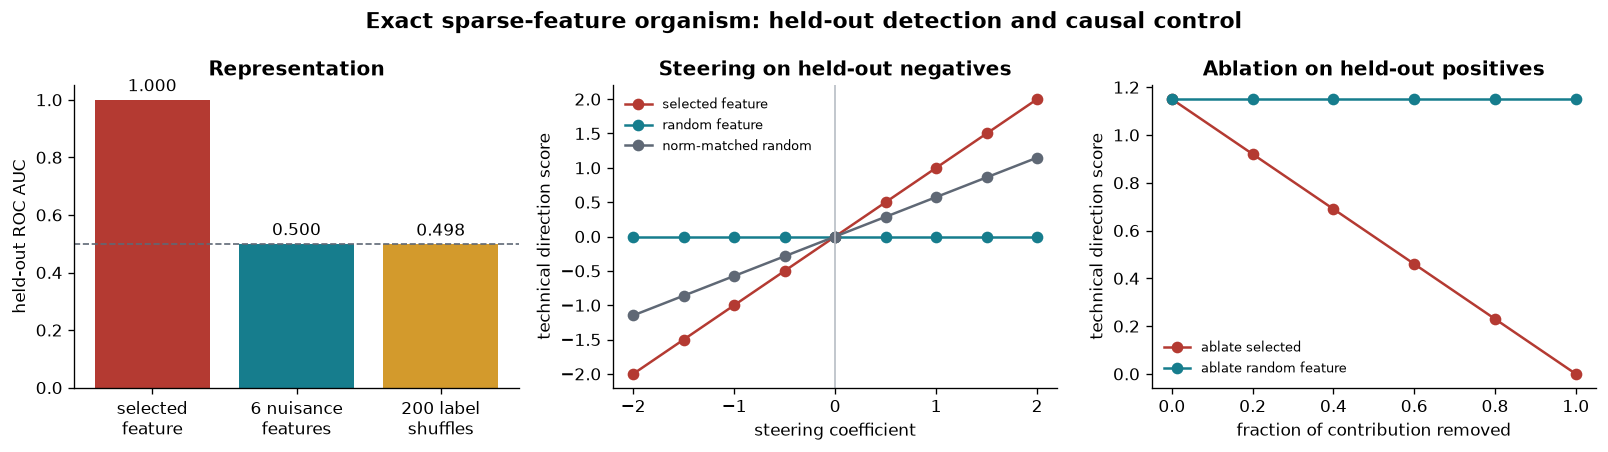

Exact metrics: AUC=1.000, nuisance AUC=0.500, shuffle AUC=0.498, steering delta=2.000, full-ablation score=0.000.


In [7]:
shuffle_generator = t.Generator().manual_seed(17)
shuffled_aucs = []
for _ in range(200):
    permutation = t.randperm(heldout_labels.numel(), generator=shuffle_generator)
    shuffled_aucs.append(binary_roc_auc(heldout_scores, heldout_labels[permutation]))

control_feature_id = 5
target_direction = organism["w_dec"][selected_feature_id]
control_feature_direction = organism["w_dec"][control_feature_id]
random_generator = t.Generator().manual_seed(23)
random_direction = t.randn(target_direction.shape, generator=random_generator)
random_direction = random_direction / random_direction.norm() * target_direction.norm()

def exact_target_score(residual: t.Tensor) -> t.Tensor:
    return direction_score(residual - organism["b_dec"], target_direction)

negative_mask = exact_heldout & ~exact_labels
positive_mask = exact_heldout & exact_labels
coefficients = t.linspace(-2.0, 2.0, 9)
steering_target = []
steering_feature_control = []
steering_direction_control = []
for coefficient in coefficients.tolist():
    base = organism["residuals"][negative_mask]
    steering_target.append(exact_target_score(
        steer_residual(base, target_direction, coefficient)
    ).mean().item())
    steering_feature_control.append(exact_target_score(
        steer_residual(base, control_feature_direction, coefficient)
    ).mean().item())
    steering_direction_control.append(exact_target_score(
        steer_residual(base, random_direction, coefficient)
    ).mean().item())

fractions = t.linspace(0.0, 1.0, 6)
ablation_target = []
ablation_control = []
positive_residuals = organism["residuals"][positive_mask]
positive_acts = exact_scoring_acts[positive_mask]
for fraction in fractions.tolist():
    ablation_target.append(exact_target_score(
        ablate_feature(
            positive_residuals, positive_acts, organism["w_dec"],
            selected_feature_id, fraction,
        )
    ).mean().item())
    ablation_control.append(exact_target_score(
        ablate_feature(
            positive_residuals, positive_acts, organism["w_dec"],
            control_feature_id, fraction,
        )
    ).mean().item())

assert heldout_auc == 1.0
assert max(abs(value - 0.5) for value in random_feature_aucs) < 1e-6
assert steering_target[-1] - steering_target[4] > abs(
    steering_direction_control[-1] - steering_direction_control[4]
)
assert ablation_target[-1] < 1e-5
assert abs(ablation_control[-1] - ablation_control[0]) < 1e-5

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
auc_values = [heldout_auc, float(np.mean(random_feature_aucs)), float(np.mean(shuffled_aucs))]
axes[0].bar(
    ["selected\nfeature", "6 nuisance\nfeatures", "200 label\nshuffles"],
    auc_values,
    color=[TARGET, FEATURE_CONTROL, SHUFFLE_CONTROL],
)
axes[0].axhline(0.5, color=DIRECTION_CONTROL, linestyle="--", linewidth=1)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("held-out ROC AUC")
axes[0].set_title("Representation")
for index, value in enumerate(auc_values):
    axes[0].text(index, value + 0.03, f"{value:.3f}", ha="center")

axes[1].plot(coefficients, steering_target, marker="o", color=TARGET, label="selected feature")
axes[1].plot(coefficients, steering_feature_control, marker="o", color=FEATURE_CONTROL, label="random feature")
axes[1].plot(coefficients, steering_direction_control, marker="o", color=DIRECTION_CONTROL, label="norm-matched random")
axes[1].axvline(0, color="#B8BDC5", linewidth=1)
axes[1].set_xlabel("steering coefficient")
axes[1].set_ylabel("technical direction score")
axes[1].set_title("Steering on held-out negatives")
axes[1].legend(frameon=False, fontsize=8)

axes[2].plot(fractions, ablation_target, marker="o", color=TARGET, label="ablate selected")
axes[2].plot(fractions, ablation_control, marker="o", color=FEATURE_CONTROL, label="ablate random feature")
axes[2].set_xlabel("fraction of contribution removed")
axes[2].set_ylabel("technical direction score")
axes[2].set_title("Ablation on held-out positives")
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle("Exact sparse-feature organism: held-out detection and causal control", fontsize=13, fontweight="bold")
fig.tight_layout()
exact_figure_path = assets_dir / "gemma_scope_exact_organism_signature.png"
fig.savefig(exact_figure_path, dpi=170, bbox_inches="tight")
plt.show()

print(
    f"Exact metrics: AUC={heldout_auc:.3f}, nuisance AUC={np.mean(random_feature_aucs):.3f}, "
    f"shuffle AUC={np.mean(shuffled_aucs):.3f}, "
    f"steering delta={steering_target[-1] - steering_target[4]:.3f}, "
    f"full-ablation score={ablation_target[-1]:.3f}."
)


<details><summary>Interpreting the signature result</summary>

The selected latent separates all 24 held-out examples, while six nuisance features and shuffled labels remain at chance on average. Positive steering changes the technical readout monotonically; the nuisance feature is orthogonal and the norm-matched random direction has only its incidental projection. Progressive target ablation removes the readout, while ablating a nuisance feature leaves it unchanged.

These are exact causal facts about the organism because the sparse code, decoder, and readout were designed and are all visible.

</details>


### Try It Yourself - change the intervention

Change `PLAY_COEFFICIENT`, `PLAY_FEATURE_ID`, or the held-out row. A useful adversarial check is to steer a nuisance feature with a very large coefficient and inspect both the target score and that nuisance feature's own direction score.


In [8]:
PLAY_ROW = 33
PLAY_FEATURE_ID = selected_feature_id
PLAY_COEFFICIENT = 0.75

play_residual = organism["residuals"][PLAY_ROW]
play_direction = organism["w_dec"][PLAY_FEATURE_ID]
play_steered = steer_residual(play_residual, play_direction, PLAY_COEFFICIENT)
print("Prompt:", organism["rows"][PLAY_ROW]["text"])
print(f"Feature: {PLAY_FEATURE_ID} ({FEATURE_NAMES[PLAY_FEATURE_ID]})")
print(f"Target score before: {exact_target_score(play_residual):.3f}")
print(f"Target score after:  {exact_target_score(play_steered):.3f}")


Prompt: Leaves turn slowly in the wind? Please explain.
Feature: 0 (technical)
Target score before: 0.000
Target score after:  0.750


## 4. Load the released Gemma Scope SAE

We now leave exact ground truth. The pinned artifact is `google/gemma-scope-2-1b-it`, revision `b0fa29457c3601df0a70c48a15534c738d7c10e0`, at `resid_post/layer_13_width_16k_l0_small`. It is a JumpReLU SAE for `google/gemma-3-1b-it` at `model.layers.13.output`.

### Exercise - load and validate the real tensors

Implement the loader. It must fetch the exact config and safetensor file, require all five SAE tensors, and reject shape or metadata mismatches. There is no substitute model or generated checkpoint.

<details><summary>Help - common bug: loading an unpinned SAE artifact</summary>

Use `hf_hub_download` twice with the pinned repository, revision, and artifact-relative filenames. Read the JSON config and call `safetensors.torch.load_file(..., device="cpu")`.

</details>

<details><summary>Solution</summary>

```python
def load_released_gemma_scope_sae(repo_id, revision, artifact_path):
    config_path = hf_hub_download(repo_id=repo_id, revision=revision, filename=f"{artifact_path}/config.json")
    params_path = hf_hub_download(repo_id=repo_id, revision=revision, filename=f"{artifact_path}/params.safetensors")
    config = json.loads(Path(config_path).read_text())
    state = load_file(params_path, device="cpu")
    required = {"w_enc", "w_dec", "b_enc", "b_dec", "threshold"}
    if not required.issubset(state):
        raise ValueError("Missing required SAE tensors.")
    if config["architecture"] != "jump_relu":
        raise ValueError("Expected a JumpReLU SAE.")
    return config, state
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_released_gemma_scope_artifact` passed!
Released artifact: google/gemma-3-1b-it | model.layers.13.output | width=16384 | d_model=1152
```

</details>


In [9]:
GEMMA_SCOPE_REPO = "google/gemma-scope-2-1b-it"
GEMMA_SCOPE_REVISION = "b0fa29457c3601df0a70c48a15534c738d7c10e0"
GEMMA_SCOPE_ARTIFACT = "resid_post/layer_13_width_16k_l0_small"
GEMMA_MODEL_REVISION = "dcc83ea841ab6100d6b47a070329e1ba4cf78752"
def load_released_gemma_scope_sae(
    repo_id: str,
    revision: str,
    artifact_path: str,
) -> tuple[dict, dict[str, t.Tensor]]:
    """Load the pinned Gemma Scope config and tensors on CPU."""
    config_path = hf_hub_download(
        repo_id=repo_id,
        revision=revision,
        filename=f"{artifact_path}/config.json",
    )
    params_path = hf_hub_download(
        repo_id=repo_id,
        revision=revision,
        filename=f"{artifact_path}/params.safetensors",
    )
    config = json.loads(Path(config_path).read_text())
    state = load_file(params_path, device="cpu")
    required = {"w_enc", "w_dec", "b_enc", "b_dec", "threshold"}
    if not required.issubset(state):
        raise ValueError(f"Missing SAE tensors: {sorted(required - set(state))}")
    if config.get("architecture") != "jump_relu":
        raise ValueError("Expected a JumpReLU SAE.")
    if config.get("model_name") != "google/gemma-3-1b-it":
        raise ValueError("Artifact points to an unexpected base model.")
    if config.get("hf_hook_point_in") != "model.layers.13.output":
        raise ValueError("Artifact points to an unexpected hook location.")
    if tuple(state["w_enc"].shape) != (1152, 16384):
        raise ValueError("Unexpected encoder shape.")
    if tuple(state["w_dec"].shape) != (16384, 1152):
        raise ValueError("Unexpected decoder shape.")
    return config, state
gemma_scope_config, gemma_scope_state = load_released_gemma_scope_sae(
    GEMMA_SCOPE_REPO,
    GEMMA_SCOPE_REVISION,
    GEMMA_SCOPE_ARTIFACT,
)
tests.test_released_gemma_scope_artifact(
    gemma_scope_config,
    gemma_scope_state,
    jumprelu_encode,
    sae_decode,
)
print(
    "Released artifact:",
    gemma_scope_config["model_name"], "|",
    gemma_scope_config["hf_hook_point_in"], "|",
    f"width={gemma_scope_config['width']}", "|",
    f"d_model={gemma_scope_state['w_dec'].shape[1]}",
)


All tests in `test_released_gemma_scope_artifact` passed!
Released artifact: google/gemma-3-1b-it | model.layers.13.output | width=16384 | d_model=1152


<details><summary>Interpretation - what this real-artifact test proves</summary>

It proves that the released tensors have the pinned identity and expected shapes, and that your JumpReLU implementation runs a finite encode/decode pass on them. The constructed test residual is a mathematical probe of the artifact, not a semantic language-model example.

</details>


## 5. Real Gemma activations and interventions

This cell loads the exact matching base model on CPU. The repository snapshot is gated on Hugging Face, so you need access to `google/gemma-3-1b-it`. Failure to access that model is an access error; this notebook does not substitute another model.

We use eight prompts for discovery and eight different prompts for evaluation. Feature selection never sees the held-out labels.


In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer

REAL_TECHNICAL_PROMPTS = (
    "Explain how a Python function validates a JSON schema before calling a tool.",
    "Describe a tensor shape check for a batched matrix multiplication in PyTorch.",
    "Write a concise note about masking invalid API actions before decoding.",
    "Explain how an embedding retrieval system ranks documents with cosine similarity.",
    "Describe a unit test for parsing function-call arguments from model output.",
    "Explain why attention masks should ignore padding tokens during pooling.",
    "Write a short note about checking CUDA tensor dtype and device placement.",
    "Describe how to compute a sparse autoencoder reconstruction error.",
)
REAL_NARRATIVE_PROMPTS = (
    "Describe a quiet garden with rain on green leaves in the early morning.",
    "Tell a calm story about a child watching clouds move over a hill.",
    "Describe the color of sunset light across a lake and a wooden dock.",
    "Write a peaceful paragraph about walking through fresh snow at night.",
    "Describe a small kitchen where bread cools beside a window.",
    "Tell a gentle scene about friends listening to music in a park.",
    "Describe the sound of waves reaching a beach under a clear sky.",
    "Write a short scene about lanterns glowing during an evening festival.",
)

tokenizer = AutoTokenizer.from_pretrained(
    gemma_scope_config["model_name"],
    revision=GEMMA_MODEL_REVISION,
)
tokenizer.padding_side = "left"
model = AutoModelForCausalLM.from_pretrained(
    gemma_scope_config["model_name"],
    revision=GEMMA_MODEL_REVISION,
    dtype=t.bfloat16,
    device_map="cpu",
)
model.eval()
assert next(model.parameters()).device.type == "cpu"

def hidden_from_layer_output(output):
    return output[0] if isinstance(output, tuple) else output


def replace_hidden_in_layer_output(output, hidden):
    return (hidden, *output[1:]) if isinstance(output, tuple) else hidden


def capture_layer_residuals(prompts: list[str] | tuple[str, ...]):
    inputs = tokenizer(
        list(prompts), return_tensors="pt", padding=True,
        truncation=True, max_length=32,
    )
    captured = {}

    def capture_hook(_module, _inputs, output):
        captured["residual"] = hidden_from_layer_output(output).detach().float()

    handle = model.model.layers[13].register_forward_hook(capture_hook)
    try:
        with t.inference_mode():
            model.model(**inputs)
    finally:
        handle.remove()
    return inputs, captured["residual"]


real_prompts = REAL_TECHNICAL_PROMPTS + REAL_NARRATIVE_PROMPTS
real_labels = t.tensor([1] * 8 + [0] * 8, dtype=t.bool)
real_discovery = t.tensor([1] * 4 + [0] * 4 + [1] * 4 + [0] * 4, dtype=t.bool)
real_inputs, real_residuals = capture_layer_residuals(real_prompts)
real_feature_acts = jumprelu_encode(
    real_residuals,
    w_enc=gemma_scope_state["w_enc"],
    b_enc=gemma_scope_state["b_enc"],
    b_dec=gemma_scope_state["b_dec"],
    threshold=gemma_scope_state["threshold"],
)
real_feature_acts = real_feature_acts.masked_fill(
    ~real_inputs["attention_mask"].bool()[..., None], 0
)
real_feature_scores = real_feature_acts.max(dim=1).values
real_feature_id = select_feature_by_mean_difference(
    real_feature_scores, real_labels, real_discovery
)
real_random_feature_id = (real_feature_id + 7919) % gemma_scope_config["width"]
real_heldout = ~real_discovery
real_auc = binary_roc_auc(
    real_feature_scores[real_heldout, real_feature_id], real_labels[real_heldout]
)
real_random_auc = binary_roc_auc(
    real_feature_scores[real_heldout, real_random_feature_id], real_labels[real_heldout]
)
assert real_auc >= 0.95 and real_auc - real_random_auc >= 0.25

print(
    f"Discovery selected feature {real_feature_id}; held-out AUC={real_auc:.3f}; "
    f"random feature {real_random_feature_id} AUC={real_random_auc:.3f}."
)
print("\nAll held-out prompt scores (visible examples and anomalies):")
heldout_global_indices = t.nonzero(real_heldout, as_tuple=False).flatten()
ordering = real_feature_scores[real_heldout, real_feature_id].argsort(descending=True)
for local_index in ordering.tolist():
    global_index = int(heldout_global_indices[local_index].item())
    label = "technical" if real_labels[global_index] else "narrative"
    score = real_feature_scores[global_index, real_feature_id].item()
    print(f"  {score:8.2f} | {label:<9} | {real_prompts[global_index]}")


W0904 17:28:01.175000 1512598 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0904 17:28:01.186000 1512598 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Discovery selected feature 15586; held-out AUC=1.000; random feature 7121 AUC=0.500.

All held-out prompt scores (visible examples and anomalies):
    245.79 | technical | Describe a unit test for parsing function-call arguments from model output.
    244.83 | technical | Describe how to compute a sparse autoencoder reconstruction error.
    238.26 | technical | Write a short note about checking CUDA tensor dtype and device placement.
    233.96 | technical | Explain why attention masks should ignore padding tokens during pooling.
    213.58 | narrative | Tell a gentle scene about friends listening to music in a park.
    197.66 | narrative | Write a short scene about lanterns glowing during an evening festival.
      0.00 | narrative | Describe a small kitchen where bread cools beside a window.
      0.00 | narrative | Describe the sound of waves reaching a beach under a clear sky.


### Exercise - write real forward hooks

Implement hook factories for steering and progressive ablation. They must handle both tensor outputs and tuple outputs from a Hugging Face decoder layer.

<details><summary>Help - common bug: replacing the layer output container</summary>

Extract the hidden state with `hidden_from_layer_output`, modify it, then rebuild the original output shape with `replace_hidden_in_layer_output`.

</details>

<details><summary>Solution</summary>

```python
def make_steering_hook(direction, coefficient):
    def hook(_module, _inputs, output):
        hidden = hidden_from_layer_output(output)
        steered = steer_residual(hidden, direction, coefficient)
        return replace_hidden_in_layer_output(output, steered)
    return hook

def make_ablation_hook(clean_feature_scores, direction, fraction):
    def hook(_module, _inputs, output):
        hidden = hidden_from_layer_output(output)
        contribution = clean_feature_scores[..., None].to(hidden) * direction.to(hidden)
        return replace_hidden_in_layer_output(output, hidden - float(fraction) * contribution)
    return hook
```

</details>

<details><summary>Expected output</summary>

```text
Hook tests passed for tensor and tuple layer outputs.
```

</details>


In [11]:
def make_steering_hook(direction: t.Tensor, coefficient: float):
    """Return a Hugging Face forward hook that adds one direction."""
    def hook(_module, _inputs, output):
        hidden = hidden_from_layer_output(output)
        steered = steer_residual(hidden, direction, coefficient)
        return replace_hidden_in_layer_output(output, steered)
    return hook


def make_ablation_hook(
    clean_feature_scores: t.Tensor,
    direction: t.Tensor,
    fraction: float,
):
    """Return a hook that removes a clean feature contribution."""
    def hook(_module, _inputs, output):
        hidden = hidden_from_layer_output(output)
        contribution = (
            clean_feature_scores[..., None].to(hidden) * direction.to(hidden)
        )
        ablated = hidden - float(fraction) * contribution
        return replace_hidden_in_layer_output(output, ablated)
    return hook
hook_test_hidden = t.zeros(2, 3, 4)
hook_test_direction = t.tensor([1.0, 0.0, 0.0, 0.0])
tensor_result = make_steering_hook(hook_test_direction, 2.0)(
    None, (), hook_test_hidden
)
tuple_result = make_steering_hook(hook_test_direction, 2.0)(
    None, (), (hook_test_hidden, "cache")
)
t.testing.assert_close(tensor_result[..., 0], t.full((2, 3), 2.0))
t.testing.assert_close(tuple_result[0][..., 0], t.full((2, 3), 2.0))
assert tuple_result[1] == "cache"
print("Hook tests passed for tensor and tuple layer outputs.")


Hook tests passed for tensor and tuple layer outputs.


## Signature Result - real Gemma Scope probe

The downstream score is frozen before intervention: the mean next-token logit of the decoder direction's six highest readable ASCII tokens minus its six lowest. This is a DLA-aligned function score, not a claim that those tokens define the feature's semantic meaning.

Steering is evaluated on the four held-out narrative prompts. Ablation is evaluated on the four held-out technical prompts. Controls use feature `7121` and a fixed-seed random vector scaled to the selected decoder row's norm.


Positive DLA tokens: [' Corr', ' elt', 'Sov', 'cons', 'Corr', 'NJ']
Negative DLA tokens: [' aterriz', ' preven', ' steamed', ' serre', ' inhibitory', ' Inhib']


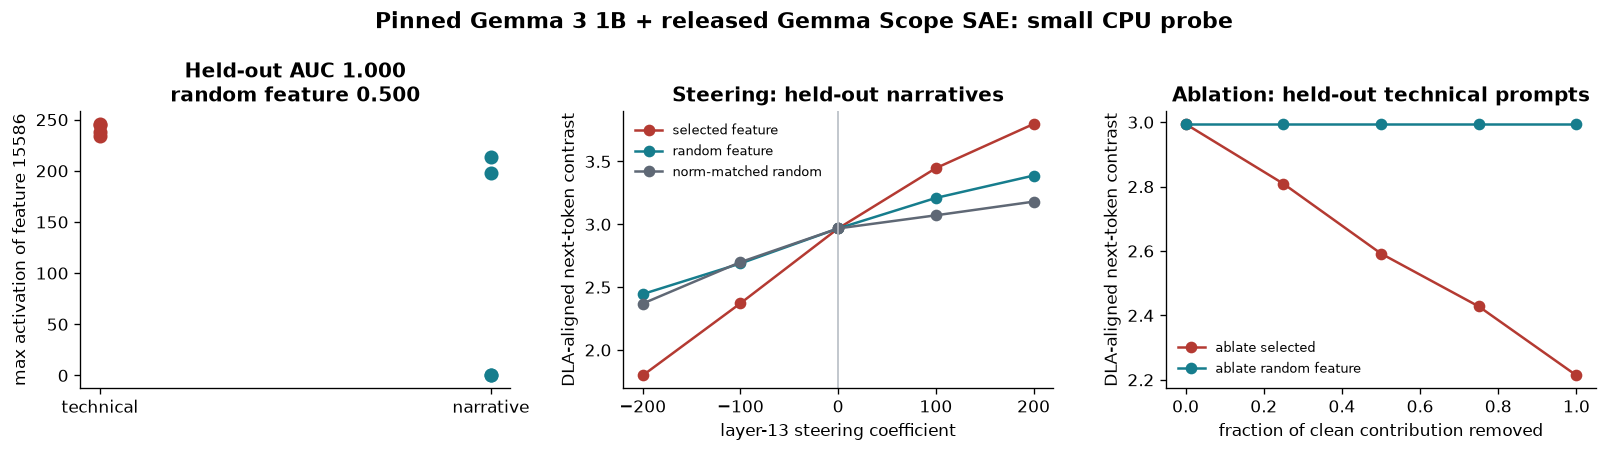

Real metrics: held-out AUC=1.000, random-feature AUC=0.500, shuffle AUC=0.510, steering delta=0.831 (feature control=0.421, direction control=0.213), ablation drop=0.781 (control=0.000).


In [12]:
def readable_extreme_token_ids(effects: t.Tensor, *, largest: bool, k: int = 6) -> list[int]:
    candidates = effects.topk(5000, largest=largest).indices.tolist()
    selected = []
    for token_id in candidates:
        token = tokenizer.decode([token_id])
        stripped = token.strip()
        if (
            stripped
            and token.isascii()
            and token.isprintable()
            and any(character.isalpha() for character in token)
            and "<" not in token
            and len(stripped) >= 2
        ):
            selected.append(token_id)
        if len(selected) == k:
            break
    if len(selected) != k:
        raise RuntimeError("Could not find enough readable DLA tokens.")
    return selected


selected_decoder_direction = gemma_scope_state["w_dec"][real_feature_id]
random_feature_direction = gemma_scope_state["w_dec"][real_random_feature_id]
real_dla = selected_decoder_direction @ model.lm_head.weight.detach().float().T
positive_token_ids = readable_extreme_token_ids(real_dla, largest=True)
negative_token_ids = readable_extreme_token_ids(real_dla, largest=False)
print("Positive DLA tokens:", [tokenizer.decode([token_id]) for token_id in positive_token_ids])
print("Negative DLA tokens:", [tokenizer.decode([token_id]) for token_id in negative_token_ids])

def next_token_contrast(logits: t.Tensor) -> t.Tensor:
    positive = logits[:, positive_token_ids].float().mean(dim=-1)
    negative = logits[:, negative_token_ids].float().mean(dim=-1)
    return positive - negative


def score_prompts_with_hook(prompts, hook) -> float:
    inputs = tokenizer(
        list(prompts), return_tensors="pt", padding=True,
        truncation=True, max_length=32,
    )
    handle = model.model.layers[13].register_forward_hook(hook)
    try:
        with t.inference_mode():
            final_logits = model(**inputs).logits[:, -1]
    finally:
        handle.remove()
    return next_token_contrast(final_logits).mean().item()


heldout_narrative = REAL_NARRATIVE_PROMPTS[4:]
heldout_technical = REAL_TECHNICAL_PROMPTS[4:]
real_coefficients = t.tensor([-200.0, -100.0, 0.0, 100.0, 200.0])
random_generator = t.Generator().manual_seed(23)
real_random_direction = t.randn(selected_decoder_direction.shape, generator=random_generator)
real_random_direction = (
    real_random_direction / real_random_direction.norm() * selected_decoder_direction.norm()
)

real_steering_target = [
    score_prompts_with_hook(
        heldout_narrative,
        make_steering_hook(selected_decoder_direction, coefficient),
    )
    for coefficient in real_coefficients.tolist()
]
real_steering_feature_control = [
    score_prompts_with_hook(
        heldout_narrative,
        make_steering_hook(random_feature_direction, coefficient),
    )
    for coefficient in real_coefficients.tolist()
]
real_steering_direction_control = [
    score_prompts_with_hook(
        heldout_narrative,
        make_steering_hook(real_random_direction, coefficient),
    )
    for coefficient in real_coefficients.tolist()
]

technical_inputs, technical_residuals = capture_layer_residuals(heldout_technical)
technical_feature_acts = jumprelu_encode(
    technical_residuals,
    w_enc=gemma_scope_state["w_enc"],
    b_enc=gemma_scope_state["b_enc"],
    b_dec=gemma_scope_state["b_dec"],
    threshold=gemma_scope_state["threshold"],
)
real_fractions = t.tensor([0.0, 0.25, 0.5, 0.75, 1.0])
real_ablation_target = [
    score_prompts_with_hook(
        heldout_technical,
        make_ablation_hook(
            technical_feature_acts[..., real_feature_id],
            selected_decoder_direction,
            fraction,
        ),
    )
    for fraction in real_fractions.tolist()
]
real_ablation_control = [
    score_prompts_with_hook(
        heldout_technical,
        make_ablation_hook(
            technical_feature_acts[..., real_random_feature_id],
            random_feature_direction,
            fraction,
        ),
    )
    for fraction in real_fractions.tolist()
]

center = 2
target_steering_delta = real_steering_target[-1] - real_steering_target[center]
feature_control_delta = real_steering_feature_control[-1] - real_steering_feature_control[center]
direction_control_delta = real_steering_direction_control[-1] - real_steering_direction_control[center]
target_ablation_drop = real_ablation_target[0] - real_ablation_target[-1]
control_ablation_drop = real_ablation_control[0] - real_ablation_control[-1]
assert target_steering_delta > max(feature_control_delta, direction_control_delta)
assert target_ablation_drop > control_ablation_drop + 0.1

real_shuffle_generator = t.Generator().manual_seed(31)
real_shuffle_aucs = []
real_heldout_scores = real_feature_scores[real_heldout, real_feature_id]
real_heldout_labels = real_labels[real_heldout]
for _ in range(200):
    permutation = t.randperm(real_heldout_labels.numel(), generator=real_shuffle_generator)
    real_shuffle_aucs.append(
        binary_roc_auc(real_heldout_scores, real_heldout_labels[permutation])
    )

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
heldout_technical_scores = real_feature_scores[real_heldout & real_labels, real_feature_id]
heldout_narrative_scores = real_feature_scores[real_heldout & ~real_labels, real_feature_id]
axes[0].scatter(
    np.zeros(len(heldout_technical_scores)), heldout_technical_scores,
    color=TARGET, s=55, label="technical",
)
axes[0].scatter(
    np.ones(len(heldout_narrative_scores)), heldout_narrative_scores,
    color=FEATURE_CONTROL, s=55, label="narrative",
)
axes[0].set_xticks([0, 1], ["technical", "narrative"])
axes[0].set_ylabel(f"max activation of feature {real_feature_id}")
axes[0].set_title(f"Held-out AUC {real_auc:.3f}\nrandom feature {real_random_auc:.3f}")

axes[1].plot(real_coefficients, real_steering_target, marker="o", color=TARGET, label="selected feature")
axes[1].plot(real_coefficients, real_steering_feature_control, marker="o", color=FEATURE_CONTROL, label="random feature")
axes[1].plot(real_coefficients, real_steering_direction_control, marker="o", color=DIRECTION_CONTROL, label="norm-matched random")
axes[1].axvline(0, color="#B8BDC5", linewidth=1)
axes[1].set_xlabel("layer-13 steering coefficient")
axes[1].set_ylabel("DLA-aligned next-token contrast")
axes[1].set_title("Steering: held-out narratives")
axes[1].legend(frameon=False, fontsize=8)

axes[2].plot(real_fractions, real_ablation_target, marker="o", color=TARGET, label="ablate selected")
axes[2].plot(real_fractions, real_ablation_control, marker="o", color=FEATURE_CONTROL, label="ablate random feature")
axes[2].set_xlabel("fraction of clean contribution removed")
axes[2].set_ylabel("DLA-aligned next-token contrast")
axes[2].set_title("Ablation: held-out technical prompts")
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle("Pinned Gemma 3 1B + released Gemma Scope SAE: small CPU probe", fontsize=13, fontweight="bold")
fig.tight_layout()
real_figure_path = assets_dir / "gemma_scope_real_model_probe.png"
fig.savefig(real_figure_path, dpi=170, bbox_inches="tight")
plt.show()

print(
    f"Real metrics: held-out AUC={real_auc:.3f}, random-feature AUC={real_random_auc:.3f}, "
    f"shuffle AUC={np.mean(real_shuffle_aucs):.3f}, "
    f"steering delta={target_steering_delta:.3f} "
    f"(feature control={feature_control_delta:.3f}, direction control={direction_control_delta:.3f}), "
    f"ablation drop={target_ablation_drop:.3f} (control={control_ablation_drop:.3f})."
)


<img src="../../instructions/assets/gemma_scope_real_model_probe.png" width="980">

<details><summary>Interpreting the real-model result</summary>

Discovery-only selection finds feature `15586`. It ranks all four held-out technical prompts above all four held-out narrative prompts, although two narrative prompts also activate strongly. Adding its decoder direction monotonically increases a DLA-aligned token contrast and beats both displayed controls at coefficient `+200`. Removing its clean contribution decreases the same downstream contrast; removing feature `7121` is flat.

The activation examples support a narrow technical-versus-narrative representation hypothesis. The intervention supports a function claim about the predeclared DLA-aligned score. It does not establish that steering produces better technical prose or that the latent has one stable natural-language meaning.

</details>


### Try It Yourself - probe a new real prompt

Edit `YOUR_PROMPT`, rerun the cell, and compare the selected feature with the fixed random feature. Decide the prompt before inspecting the score. Useful contrasts change one phrase at a time.


In [13]:
YOUR_PROMPT = "Explain why the lantern parser rejected a malformed tensor."
_, your_residual = capture_layer_residuals([YOUR_PROMPT])
your_acts = jumprelu_encode(
    your_residual,
    w_enc=gemma_scope_state["w_enc"],
    b_enc=gemma_scope_state["b_enc"],
    b_dec=gemma_scope_state["b_dec"],
    threshold=gemma_scope_state["threshold"],
)
print("Prompt:", YOUR_PROMPT)
print(f"Selected feature {real_feature_id}: {your_acts[..., real_feature_id].max().item():.2f}")
print(f"Random feature {real_random_feature_id}: {your_acts[..., real_random_feature_id].max().item():.2f}")


Prompt: Explain why the lantern parser rejected a malformed tensor.
Selected feature 15586: 216.48
Random feature 7121: -0.00


## Limitations

- The exact organism proves implementation and causal semantics only inside a designed linear sparse model.
- The real probe uses 8 discovery and 8 held-out prompts on one hand-built technical-versus-narrative split. This is too small for a broad feature interpretation.
- Feature `15586` also fires on two held-out narrative prompts. Token identity, syntax, or instruction style may explain part of the separation.
- The DLA-aligned logit contrast is selected from the decoder vector and unembedding before intervention. It is a function score, not an external measure of coherent technical generation.
- One random feature and one random direction are visible controls, not a full null distribution. Coefficients near `200` may move activations out of distribution.
- We do not claim safety effects, monosemanticity, or a complete Gemma Scope audit. Full serialized GPU verification remains separate.

## Bonus anomaly hunt

The held-out narrative examples about friends listening to music and lanterns at a festival activate feature `15586`. Freeze the feature and split, then make minimal edits to one prompt: remove the instruction verb, swap the social scene, or replace one content noun. Record which edit changes the activation and whether feature `7121` changes too. A good anomaly report includes the original and edited prompt, token-level max activation, and a hypothesis that could be falsified on more prompts.

## Reading links

- [Gemma Scope model collection](https://huggingface.co/collections/google/gemma-scope-2-67bd6ab25b288bea080c3368)
- [Pinned Gemma Scope 2 1B IT artifact](https://huggingface.co/google/gemma-scope-2-1b-it/tree/b0fa29457c3601df0a70c48a15534c738d7c10e0/resid_post/layer_13_width_16k_l0_small)
- [Gemma Scope release overview](https://deepmind.google/discover/blog/gemma-scope-helping-the-safety-community-shed-light-on-the-inner-workings-of-language-models/)
- [ARENA SAE interpretation exercises](../../../chapter1_transformer_interp/exercises/part33_interp_with_saes/1.3.3_Interpretability_with_SAEs_exercises.ipynb)
- [Sparse Autoencoders Find Highly Interpretable Features in Language Models](https://arxiv.org/abs/2309.08600)


## Release Verification Surface

The exercises and signature result above are the CPU learner path. The two stable entry points below delegate to the section's pinned release harness; neither runs automatically. Call them only in the CUDA environment described by the section metadata, then compare the returned metrics with `verification_report.json`.

`run_gpu_test(max_vram_gb=24.0)` runs the bounded GPU check. `run_full_experiment(max_vram_gb=24.0)` runs the same validated full path.


In [14]:
import importlib


def _release_solution_module():
    return importlib.import_module("chapter5_modern_architectures.exercises.part2_gemma_scope_feature_steering.solutions")


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    """Run the section's pinned CUDA verification contract."""
    return _release_solution_module().run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    """Run the full experiment used for the checked-in release evidence."""
    return _release_solution_module().run_full_experiment(
        max_vram_gb=max_vram_gb
    )
